# 4. Two ground stations and multiple satellite nodes

This companion extends the FSO/QKD project to a **trusted satellite relay network**.
It connects spherical-Earth geometry, optical contacts, per-link key-rate benchmarks
and the best available route between **Ground A** and **Ground B**.

The project sequence is: **1 — Basic LOS FSO; 2 — Ground Station and Satellite;
3 — Two Ground and One Satellite; 4 — Two Ground and Two or More Satellites as Nodes.**

All numerical inputs are illustrative. The plots use the independent Python reference
for the corresponding Octave extension. Run cells from top to bottom; the executed HTML
companion opens directly in a browser. Parameters are edited in section 2 below.

## 1. What the satellite nodes do

Each available optical link creates a shared pairwise key between its two endpoints.
Trusted satellite nodes can relay a ground-to-ground key with authenticated classical
messages, consuming one bit of link key on every hop for each delivered end-to-end bit.
**Every relay must be trusted.** Relays hold classical keys; this model has no entanglement
swapping, quantum memories or quantum repeaters. A satellite trusted-relay experiment
motivates the single-satellite case ([Liao et al., 2018](https://arxiv.org/abs/1801.04418)).
Inter-satellite trusted networks motivate extending that graph
([Vergoossen et al., 2020](https://arxiv.org/abs/1903.07845)).

Each candidate edge has its own optical terminals and full pulse-rate budget. Thus one
satellite can operate several links at the same time; adding nodes or edges can increase
total hardware and pulse resources. Shared keys are modeled as **undirected capacities**,
although ground-link optical pulses use the satellite-to-ground downlink budget.

At each time sample, one route is selected to maximize its weakest link:

$$K_{AB}(t)=\max_{P:A\rightarrow B}\min_{e\in P}K_e(t).$$

Only positive-key edges enter the routing graph. No route gives zero delivery rate.
The integral $\int K_{AB}(t)\,dt$ is a simultaneous-route **ideal asymptotic benchmark**,
assuming negligible relay/authentication overhead. It is not a generated key string,
a certified finite-key length, or a multi-route maximum flow. No cross-time inventory
scheduler is used for this route integral.

In [1]:
from dataclasses import asdict, replace
from pathlib import Path
import sys

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

# Open from the stage folder, project root, or any folder inside the project.
project_root = next(candidate for candidate in (Path.cwd(), *Path.cwd().parents)
                    if (candidate / "4-Two Ground and Multiple Satellites" / "network_model.py").exists())
stage_dir = project_root / '4-Two Ground and Multiple Satellites'
sys.path.insert(0, str(stage_dir))
from network_model import parameters_for_stage, simulate_network
from network_report import plot_topology, plot_links, plot_delivery, export_report, route_label

stage = 4

def table(headers, rows):
    def cell(value):
        return str(value).replace("|", "&#124;").replace("\n", "<br>")
    display(Markdown("| " + " | ".join(map(cell, headers)) + " |\n| " +
                     " | ".join("---" for _ in headers) + " |\n" +
                     "\n".join("| " + " | ".join(map(cell, row)) + " |" for row in rows)))


## 2. Edit the scenario

Ground stations sit on the same great-circle plane at central angles
$\pm d/(2R_E)$. Satellites follow one circular, coplanar orbit at equal angular
speed $\omega=\sqrt{\mu_E/(R_E+h)^3}$. Their starting phases are equally spaced
across the chosen satellite span. Earth rotation, orbital inclinations and real
ephemerides are omitted.

Times are centered at zero. Use an odd sample count so the midpoint is included.
The station separation is an Earth-surface arc distance, not a straight chord.

In [2]:
p = parameters_for_stage(stage)
# Edit any of these parameters, then rerun the following cells:
p = replace(p,
            satellite_count=2,
            ground_separation_km=3000,
            duration_s=1200,
            time_points=601)
# Hardware example: p = replace(p, link=replace(p.link, receiver_radius_m=0.7))
# Stage 4 only: change satellite_count to any integer from 2 to 12.
# Keep the span fixed for a count comparison, or change satellite_span_deg explicitly.
p.validate()
result = simulate_network(p)
table(["Input", "Value", "Interpretation"], [
    ["Ground-station arc separation", f"{p.ground_separation_km:g} km", "Static spherical Earth"],
    ["Satellites / altitude", f"{p.satellite_count} / {p.link.altitude_km:g} km", "One common circular orbit"],
    ["Satellite phase span", f"{p.satellite_span_deg:.4f} degrees", "Equally spaced starting phases"],
    ["Window / samples", f"{p.duration_s:g} s / {p.time_points}", "Trapezoidal quadrature"],
    ["Ground-contact elevation cutoff", f"{p.link.minimum_elevation_deg:g} degrees", "Contacts below cutoff are unavailable"],
    ["Ground / ISL divergence", f"{p.link.divergence_rad*1e6:g} / {p.isl_divergence_rad*1e6:g} microrad", "Gaussian beam half-angle"],
    ["Ground / ISL receiver radius", f"{p.link.receiver_radius_m:g} / {p.isl_receiver_radius_m:g} m", "Centered collection aperture"],
    ["Ground atmosphere loss at zenith", f"{p.link.zenith_atmosphere_loss_db:g} dB", "Effective finite atmospheric shell"],
    ["ISL clearance above Earth", f"{p.isl_clearance_km:g} km", "Minimum segment radius must exceed R + clearance"],
    ["Pulse rate / signal duty per edge", f"{p.link.pulse_rate_hz/1e6:g} MHz / {p.link.signal_duty:g}", "Independent resources for each edge"],
])

| Input | Value | Interpretation |
| --- | --- | --- |
| Ground-station arc separation | 3000 km | Static spherical Earth |
| Satellites / altitude | 2 / 500 km | One common circular orbit |
| Satellite phase span | 26.9796 degrees | Equally spaced starting phases |
| Window / samples | 1200 s / 601 | Trapezoidal quadrature |
| Ground-contact elevation cutoff | 10 degrees | Contacts below cutoff are unavailable |
| Ground / ISL divergence | 10 / 2 microrad | Gaussian beam half-angle |
| Ground / ISL receiver radius | 0.5 / 0.3 m | Centered collection aperture |
| Ground atmosphere loss at zenith | 2 dB | Effective finite atmospheric shell |
| ISL clearance above Earth | 20 km | Minimum segment radius must exceed R + clearance |
| Pulse rate / signal duty per edge | 100 MHz / 0.8 | Independent resources for each edge |

## 3. Optical links and QKD benchmark

A ground link is available only when its **actual** elevation is nonnegative
and meets the elevation cutoff. The inherited stage-2 downlink model applies
atmospheric attenuation only to a finite shell near Earth, while the Gaussian
beam spreads over the full slant range. Negative elevations are masked after
evaluating a clamped elevation; below-horizon links cannot create keys.

An inter-satellite link (ISL) is available only if its finite line segment clears
Earth plus the selected clearance. ISLs use their own divergence, receiver radius,
pointing loss and background yield, with **no atmospheric attenuation**. Their
constant same-orbit angular separations give constant link distances here.

For a path length $L$ in metres and receiver radius $a$,

$$w(L)=\sqrt{w_0^2+(\vartheta L)^2},\qquad
  \eta_g=1-\exp[-2a^2/w(L)^2].$$

Total detection efficiency includes aperture collection, pointing, optical and
detector efficiencies, plus ground-link atmospheric loss. With mean signal photon
number $\mu$, background yield $Y_0$, and optical error $e_d$,

$$S=1-e^{-\mu\eta},\quad Q_\mu=S+(1-S)Y_0,\quad
  E_\mu=\frac{e_dS+\tfrac12(1-S)Y_0}{Q_\mu}.$$

The stage-2 model supplies $Y_1=\eta+(1-\eta)Y_0$ and its corresponding $e_1$.
The per-edge model-known infinite-decoy benchmark is

$$K_e=f_p p_s q\max\{\mu e^{-\mu}Y_1[1-h_2(e_1)]
  -f_{EC}Q_\mu h_2(E_\mu),0\}.$$

This is the asymptotic decoy-state rate form
([Ma et al., 2005](https://arxiv.org/abs/quant-ph/0503005)), evaluated using
known model quantities rather than statistical decoy estimates. Unavailable
contacts have zero efficiency/rate and undefined QBER (`NaN`). Geometric
availability alone does not guarantee a positive secret-key benchmark.

## 4. Network snapshot and contacts

The snapshot selects a time with the highest computed route capacity. Orange
segments show the selected route; labels show each hop's capacity. The lowest
capacity on that route sets its end-to-end rate. The graph has no direct
ground-to-ground edge. Ground nodes use triangles and satellites use circles.

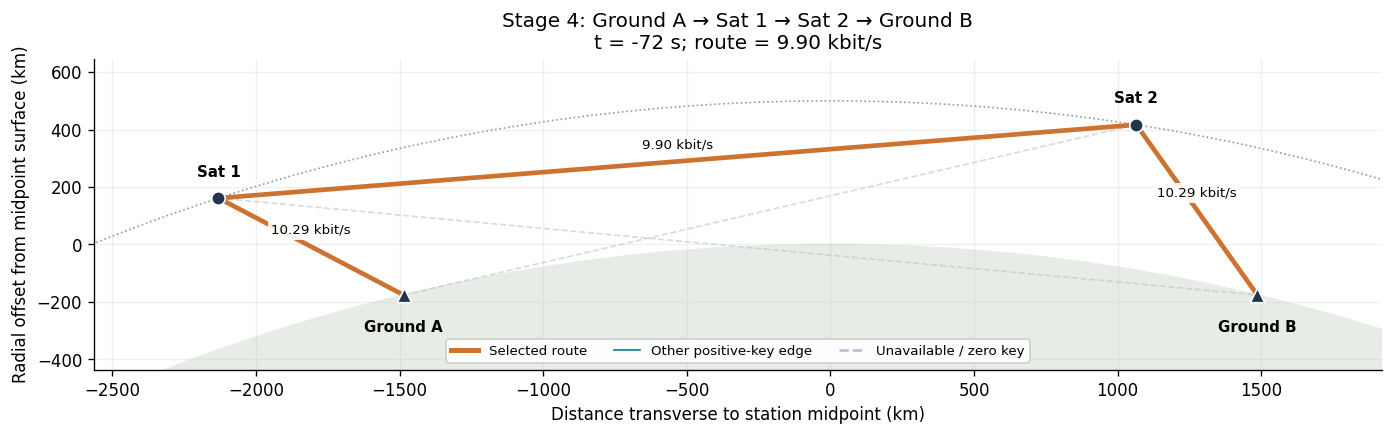

Selected route: Ground A → Sat 1 → Sat 2 → Ground B


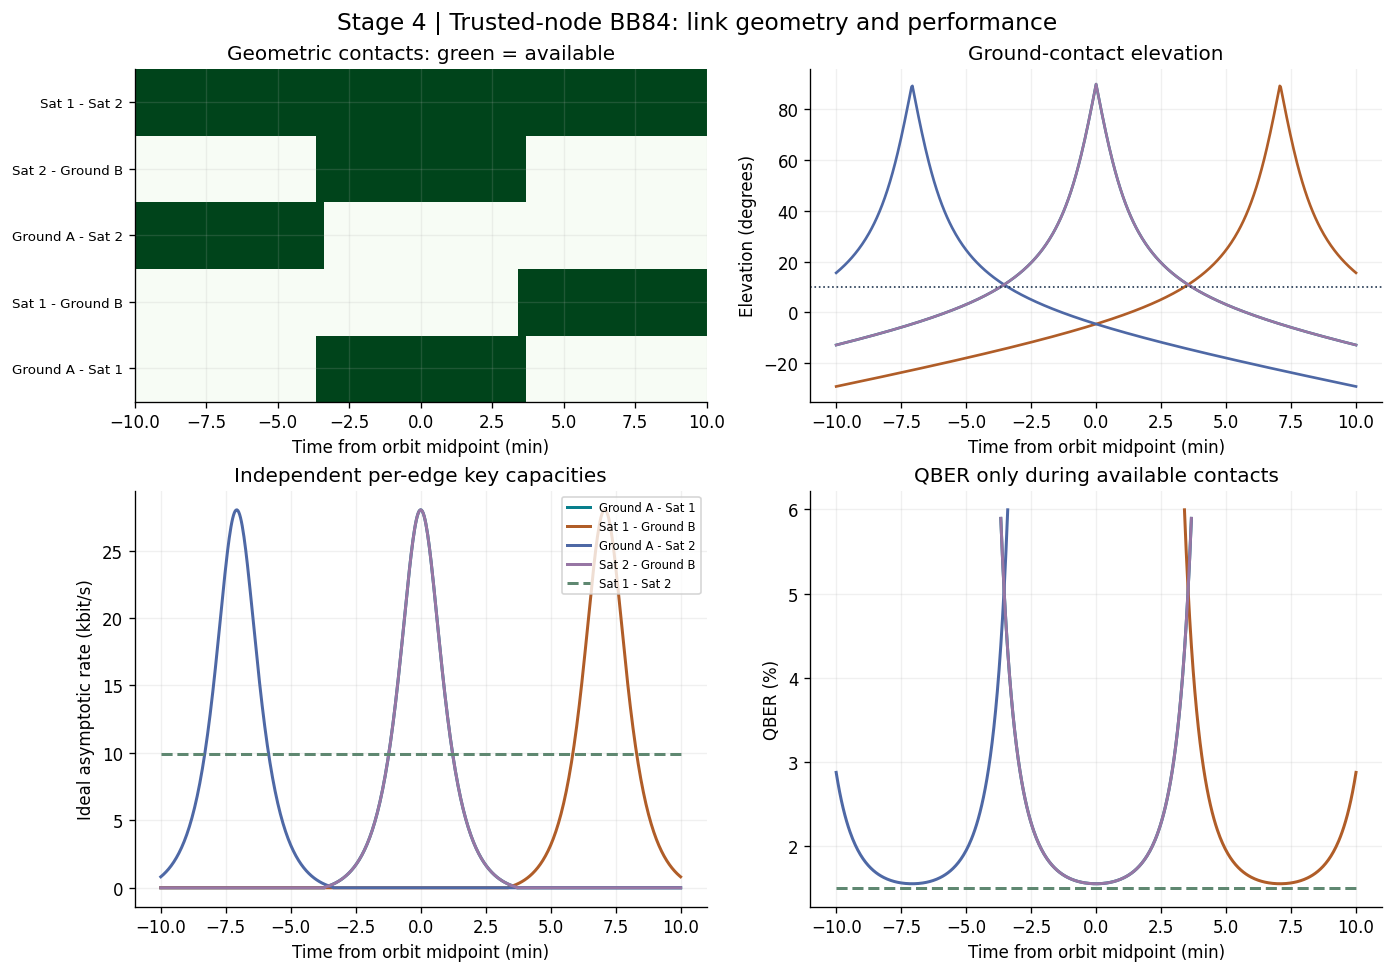

In [3]:
plot_topology(result)
plt.show()
print("Selected route:", route_label(result, result["metrics"]["best_index"]))
plot_links(result)
plt.show()

## 5. Ground-to-ground route performance

At each sample the widest-path algorithm maximizes the bottleneck across all
allowed single routes. Equal relaxations retain the first predecessor and node
ties choose the lowest index, making the result reproducible. The trapezoidal
integral of the positive-route indicator estimates connected duration; the
route-rate integral estimates simultaneous ideal key delivery.

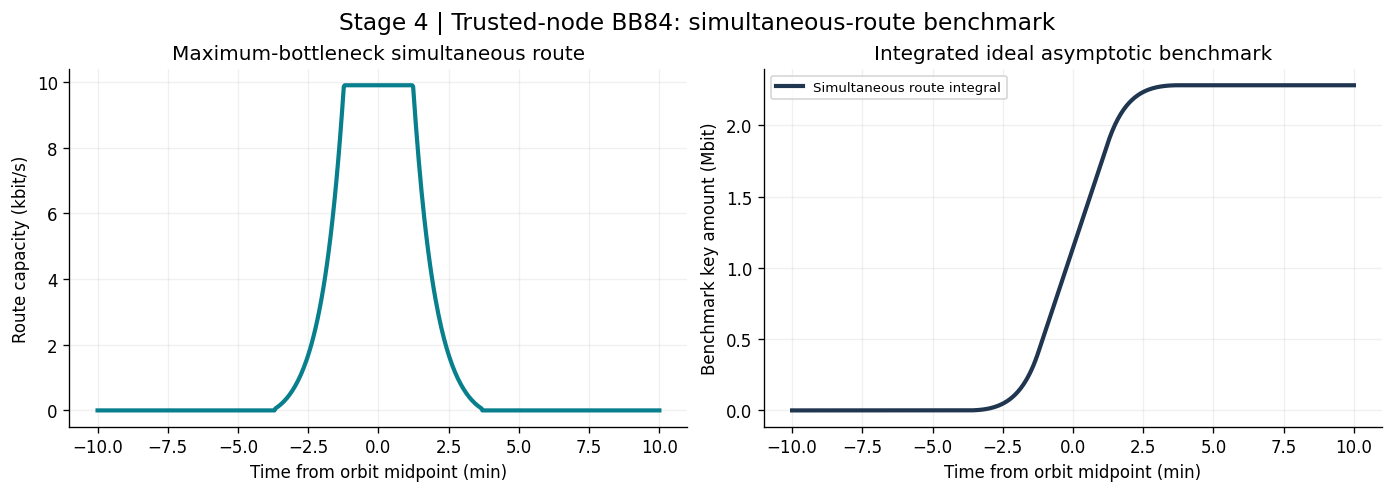

| Metric | Result |
| --- | --- |
| Peak simultaneous route capacity | 9.898 kbit/s |
| Integrated simultaneous benchmark | 2,281,947.4 bits |
| Positive-route duration (sampled trapezoid) | 442.0 s |
| Best sampled time | -72 s |

| Edge | Peak rate (kbit/s) | Integrated capacity (Mbit) |
| --- | --- | --- |
| Ground A - Sat 1 | 28.022 | 3.7574 |
| Sat 1 - Ground B | 28.017 | 3.7407 |
| Ground A - Sat 2 | 28.017 | 3.7407 |
| Sat 2 - Ground B | 28.022 | 3.7574 |
| Sat 1 - Sat 2 | 9.898 | 11.8770 |

In [4]:
plot_delivery(result)
plt.show()
metrics = result["metrics"]
summary = [
    ["Peak simultaneous route capacity", f'{metrics["peak_rate_bps"]/1000:.3f} kbit/s'],
    ["Integrated simultaneous benchmark", f'{metrics["integrated_key_bits"]:,.1f} bits'],
    ["Positive-route duration (sampled trapezoid)", f'{metrics["connected_duration_s"]:.1f} s'],
    ["Best sampled time", f'{result["time_s"][metrics["best_index"]]:g} s'],
]
if stage == 3:
    summary.append(["Post-window stored-pair bound", f'{metrics["stored_pair_bits"]:,.1f} bits'])
table(["Metric", "Result"], summary)
table(["Edge", "Peak rate (kbit/s)", "Integrated capacity (Mbit)"], [
    [edge["label"], f'{np.max(edge["key_rate_bps"])/1000:.3f}',
     f'{edge["cumulative_key_bits"][-1]/1e6:.4f}'] for edge in result["edges"]
])

## 6. Add satellite nodes: compare two, three and four

The comparison keeps the two endpoint satellite phases, ground geometry,
hardware settings and observation window fixed. Additional satellites are
inserted evenly into that same phase span. Every new edge receives an
independent terminal/pulse budget, so this is a topology-and-resource
comparison, not a fixed-total-power optimization.

Shorter ISL hops can improve the route until ground links become the
bottleneck. Consequently, adding another node need not improve the result.
This route calculation has no multi-route flow or stored-key scheduling.

| Satellites | Candidate edges | Peak route (kbit/s) | Integrated benchmark (Mbit) |
| --- | --- | --- | --- |
| 2 | 5 | 9.898 | 2.2819 |
| 3 | 9 | 28.022 | 3.7574 |
| 4 | 14 | 28.022 | 3.7574 |

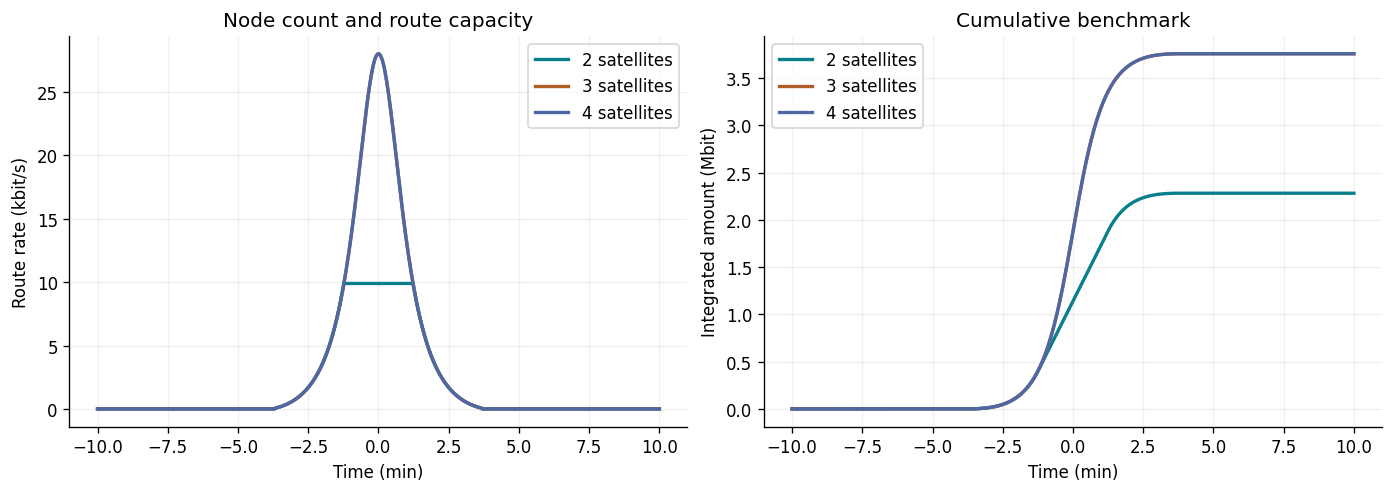

In [5]:
comparisons = [(count, simulate_network(replace(p, satellite_count=count))) for count in (2, 3, 4)]
table(["Satellites", "Candidate edges", "Peak route (kbit/s)", "Integrated benchmark (Mbit)"], [
    [count, len(item["edges"]), f'{item["metrics"]["peak_rate_bps"]/1000:.3f}',
     f'{item["metrics"]["integrated_key_bits"]/1e6:.4f}'] for count, item in comparisons
])
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4), layout="constrained")
for count, item in comparisons:
    axes[0].plot(item["time_s"]/60, item["route_rate_bps"]/1000, label=f"{count} satellites", linewidth=2)
    axes[1].plot(item["time_s"]/60, item["cumulative_key_bits"]/1e6, label=f"{count} satellites", linewidth=2)
axes[0].set(title="Node count and route capacity", xlabel="Time (min)", ylabel="Route rate (kbit/s)")
axes[1].set(title="Cumulative benchmark", xlabel="Time (min)", ylabel="Integrated amount (Mbit)")
for ax in axes:
    ax.legend()
plt.show()

## 7. Verify that the ISLs actually bridge stations

At the default 3000 km separation, the contact regions overlap slightly, so
disabling ISLs can leave a small single-satellite route. The deliberately
wider 4500 km case below removes that overlap. Three satellites with clear
neighbor ISLs reconnect the stations; disabling ISLs removes the route.

| 4500 km scenario | Integrated route benchmark (Mbit) | Connected duration (s) |
| --- | --- | --- |
| ISLs enabled | 3.1670 | 442.0 |
| ISLs disabled | 0.0000 | 0.0 |

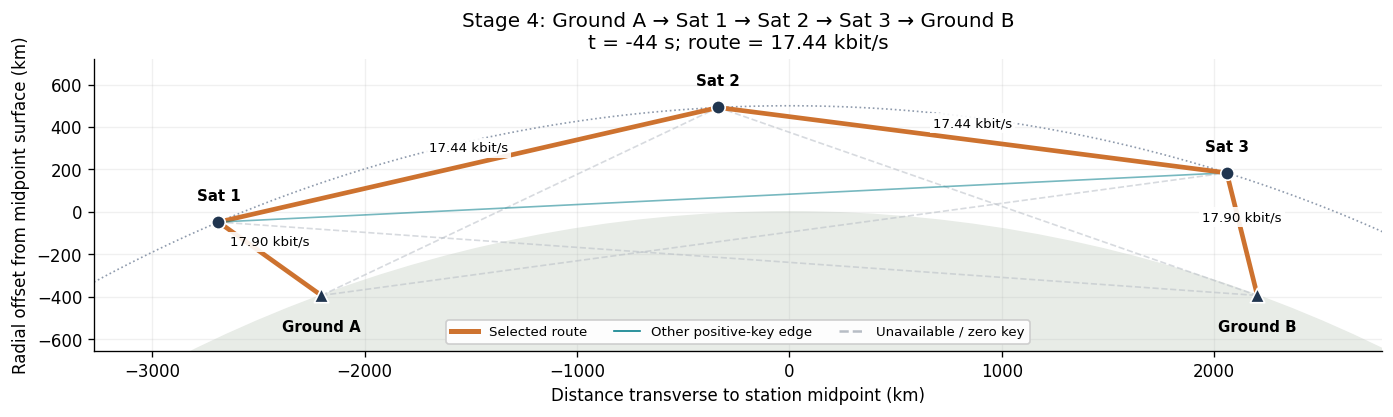

In [6]:
bridge_parameters = replace(p, satellite_count=3, ground_separation_km=4500,
                            satellite_span_deg=np.rad2deg(4500/p.link.earth_radius_km))
bridge = simulate_network(bridge_parameters)
disconnected = simulate_network(replace(bridge_parameters, enable_isl=False))
table(["4500 km scenario", "Integrated route benchmark (Mbit)", "Connected duration (s)"], [
    [label, f'{item["metrics"]["integrated_key_bits"]/1e6:.4f}',
     f'{item["metrics"]["connected_duration_s"]:.1f}']
    for label, item in [("ISLs enabled", bridge), ("ISLs disabled", disconnected)]
])
plot_topology(bridge)
plt.show()

## 8. Export and reproduce

The helper exports an HTML report, PNG figures, long-form edge data, route data
and a JSON parameter/metric summary. Python node indices and `best_index` are
zero-based; Octave uses one-based indices. CSV QBER and ISL elevation are blank
when undefined. Position arrays have shape `(time, node, xyz)` with `z = 0`.
The build script and notebooks locate the project from their own directories.

In [7]:
output_dir = stage_dir / "python_results"
outputs = export_report(result, output_dir)
for label, path in outputs.items():
    print(f"{label}: {path.relative_to(project_root)}")

topology: 4-Two Ground and Multiple Satellites\python_results\topology.png
links: 4-Two Ground and Multiple Satellites\python_results\links.png
delivery: 4-Two Ground and Multiple Satellites\python_results\delivery.png
routes: 4-Two Ground and Multiple Satellites\python_results\routes.csv
edges: 4-Two Ground and Multiple Satellites\python_results\edges.csv
summary: 4-Two Ground and Multiple Satellites\python_results\summary.json
html: 4-Two Ground and Multiple Satellites\python_results\report.html


## 9. Interpretation and limitations

- Geometry is an ideal static spherical Earth with coplanar circular satellites.
  Real coverage needs orbit ephemerides, ground coordinates and Earth rotation.
- Ground links have clear-sky effective-shell attenuation and a simple Gaussian
  beam budget. Clouds, weather, turbulence, scintillation, tracking acquisition,
  Doppler constraints and pointing jitter are not simulated.
- Independent per-edge optical terminals and pulse budgets allow simultaneous
  operation. No shared-terminal or energy scheduling constraints are imposed.
- Trusted relays expose the end-to-end key to participating satellite nodes.
  This stage has no quantum repeater, quantum memory or entanglement protocol.
- Model-known infinite-decoy asymptotic rates exclude statistical decoy bounds,
  finite-key penalties and authentication/relay costs. These are benchmarks,
  not certified secret keys or a simulated LDPC/hash transcript.
- The route benchmark chooses a single simultaneous route. It does not add
  multiple routes, optimize total flow or schedule stored-key inventories.
- Contacts and rates are sampled; connected duration and key integrals depend
  on time resolution. Increase `time_points` to examine convergence.

Validation uses this stage's local `test_network_model.py` and corresponding
Octave tests. A deterministic JSON fixture compares both implementations for
one, two, three and four satellites, plus disabled inter-satellite links.

## 10. DPS protocol statistics and atmospheric fading

This extension uses `shared/physics.py`, `shared/scenarios.py` and `shared/reporting.py`.
Earlier sections retain their historical deterministic models and finite BB84 demonstrations.
**DPS uses relative phases between coherent pulses, a one-pulse delay interferometer,
two threshold detectors and explicit valid-slot accounting.** It is not the earlier DPS teaching curve.

**DPS protocol QBER** is a detection statistic. **DPS illustrative rate proxy** uses a
collision-inspired privacy term from the restricted individual-attack analysis, combined
with the detector model described in `DPS_THEORY.md`. A DPS-specific composable secret-key
security bound has not been implemented or established. Its integral is an integrated
proxy, not certified secret-key material. The old BB84/Eve/LDPC/Toeplitz example is not DPS.

Fading is a normalized collected-power multiplier: `exp(sigma*X - sigma**2/2)`;
`sigma**2` is log-irradiance variance. Temporal correlation is phenomenological,
with `rho=exp(-dt/tau_c)` and stationary initialization. The detector factor is fixed;
optical clipping is reported. Ground links have independent random streams; vacuum
inter-satellite links do not receive atmospheric fading. No measured data are used.

Change the protocol and mode below, then restart and run all. Defaults here explicitly
select correlated fading for comparison; library defaults remain `none`.
Stage 3 retains trusted BB84/DPS and separate BBM92 operation. BBM92 always requires
simultaneous visibility and recalculates singles and accidental coincidences on both arms.
Hardware, source, clock resources and security assumptions differ across protocols.


Active protocol: DPS QKD
DPS parameters: {
  "mean_photons": 0.1,
  "visibility": 0.98,
  "phase_error_rad": 0.0,
  "background_per_detector": 1e-06,
  "ec_efficiency": 1.16,
  "pulse_rate_hz": 100000000.0,
  "duty": 0.8,
  "train_pulses": 1024,
  "guard_slots": 1
}
Fading parameters: {
  "mode": "correlated_lognormal",
  "sigma": 0.3,
  "correlation_time_s": 2.0,
  "seed": 123
}
DPS illustrative rate proxy; no composable security bound established; route and inventory are proxy budgets


| Quantity (units in field name) | Value |
|---|---|
| mean_rate_bps | 789.8109031200162 |
| median_rate_bps | 0.0 |
| p05_rate_bps | 0.0 |
| outage_fraction | 0.7670549084858569 |
| time_outage_fraction | 0.7666666666666667 |
| integrated_rate_bits | 949352.7055502587 |

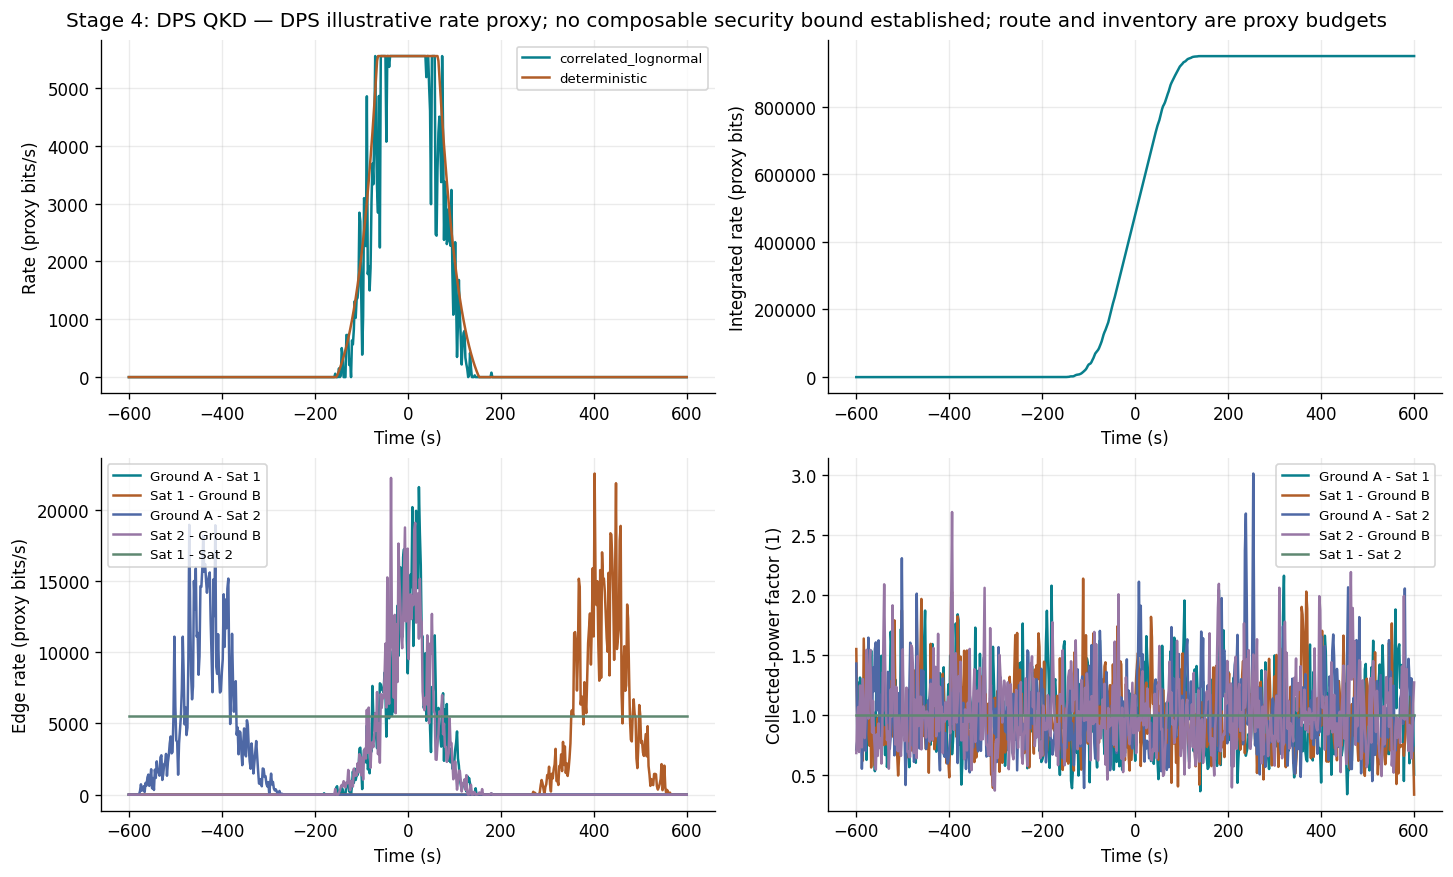

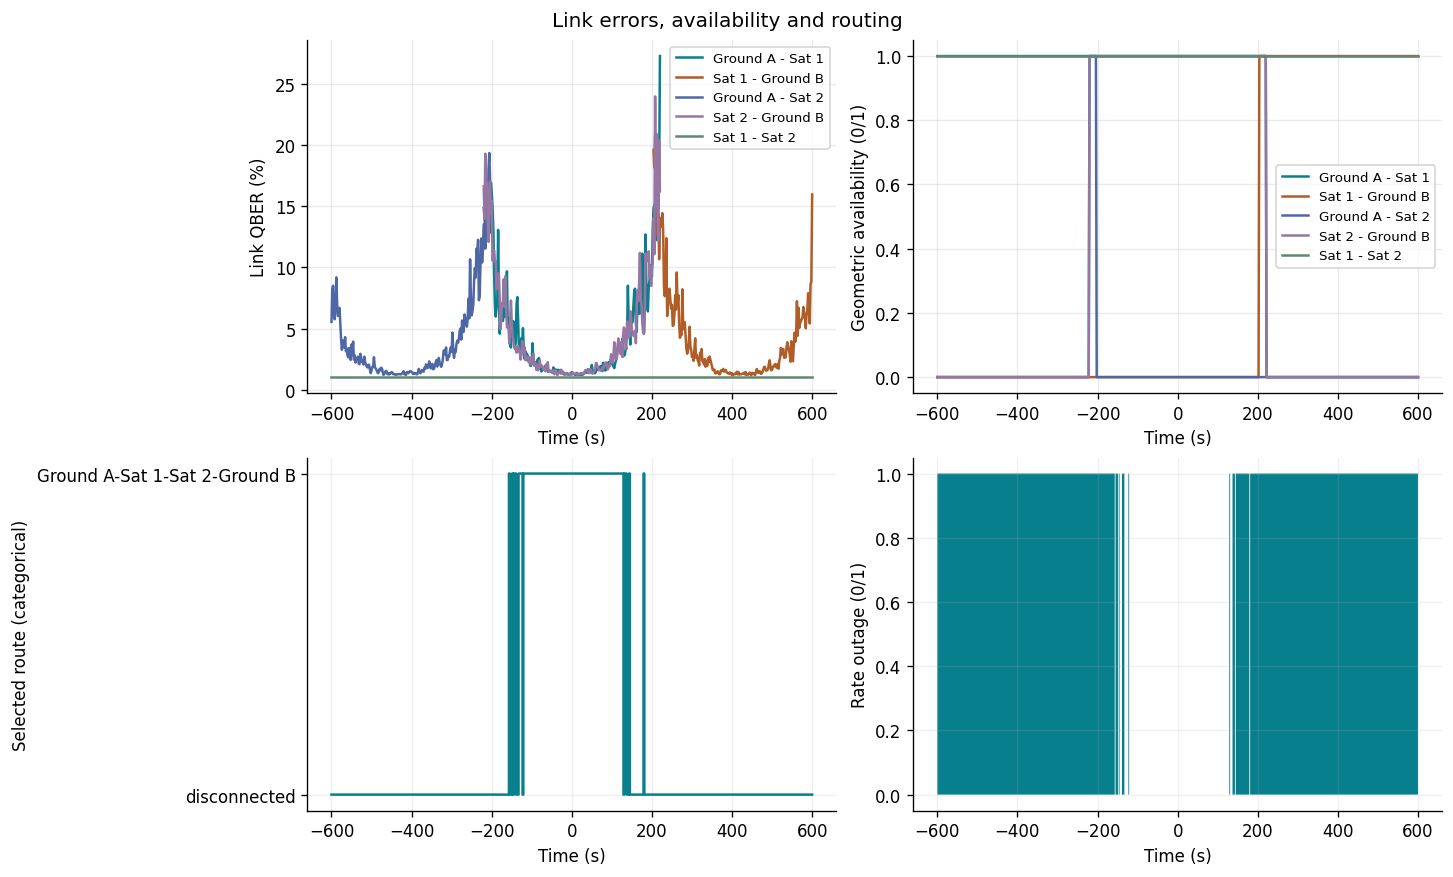

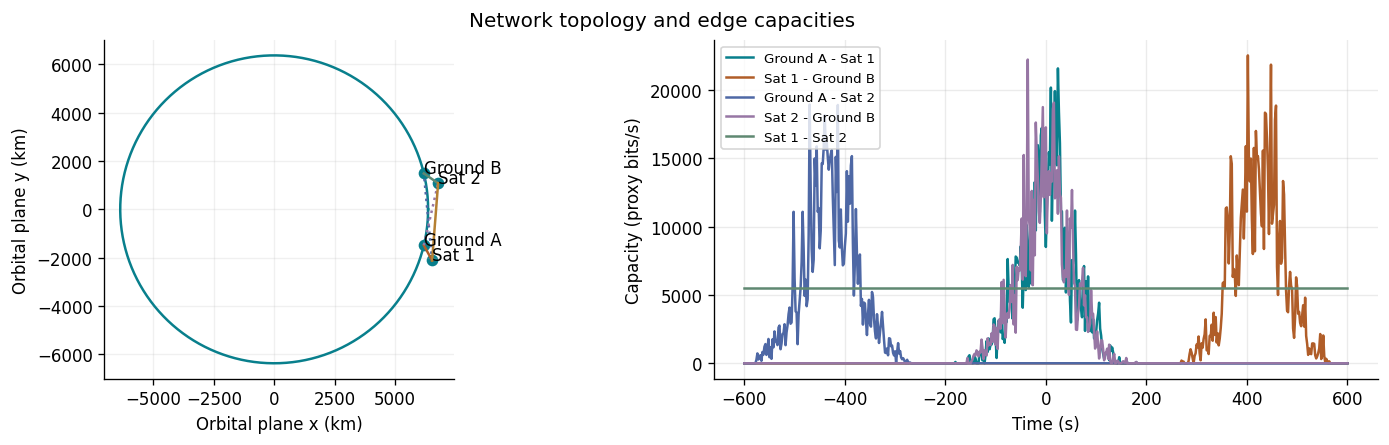

Exports: d:\IIT Class\Project\Submission\4-Two Ground and Multiple Satellites\dps_turbulence_notebook_results


In [8]:
from pathlib import Path
import sys, json
from dataclasses import asdict
from IPython.display import display, Markdown, Image
project_root = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "shared" / "physics.py").is_file())
if str(project_root) not in sys.path: sys.path.insert(0, str(project_root))
from shared.physics import DPSParameters, FadingParameters
from shared.scenarios import run_stage
from shared.reporting import export_result, plot_result, study
import matplotlib.pyplot as plt

active_protocol = "DPS QKD"  # Stage 1: BB84, Decoy-state BB84, DPS QKD; others: latter two
architecture = "trusted"    # Stage 3 only: trusted or bbm92
dps_settings = DPSParameters()
fading_settings = FadingParameters(mode="correlated_lognormal", sigma=0.3, correlation_time_s=2.0, seed=123)
extra = {"mode": architecture} if 4 == 3 else {}
extension_result = run_stage(4, protocol=active_protocol, fading=fading_settings, dps=dps_settings, **extra)
extension_baseline = run_stage(4, protocol=active_protocol, dps=dps_settings, **extra)
print("Active protocol:", extension_result["metadata"]["protocol"])
print("DPS parameters:", json.dumps(asdict(dps_settings), indent=2))
print("Fading parameters:", json.dumps(asdict(fading_settings), indent=2))
print(extension_result["metadata"]["security_status"])
summary_rows = "\n".join(f"| {k} | {v} |" for k,v in extension_result["summary"].items())
display(Markdown("| Quantity (units in field name) | Value |\n|---|---|\n" + summary_rows))
extension_figures = plot_result(extension_result, extension_baseline)
plt.show()
for extension_figure in extension_figures: plt.close(extension_figure)
extension_folder = project_root / '4-Two Ground and Multiple Satellites' / "dps_turbulence_notebook_results"
export_result(extension_result, extension_folder)
print("Exports:", extension_folder)


### Interpretation, ensemble study and exports

Mean instantaneous QBER excludes undefined zero-detection samples. Pooled QBER is total
expected errors divided by total expected detections. They generally differ. Sample outage
and time-weighted outage are both exported. Mean instantaneous rate and the rate at mean
efficiency also differ; the latter is a hypothetical continuously open link, not a pass average.
For unavailable satellite contacts, the detection gates are closed and rates are zero.

The following reproducible **default DPS design study** is separate from the selected run above.
It uses fixed geometry and 12 independent seeds, plus five seeds at each turbulence strength.
The plotted sample intervals are descriptive, not confidence bounds or proof of a general trend.
Monte Carlo histograms have sample-count axes, not seconds. All zero rates remain zero.
Reports contain parameters, assumptions, units, seeds, CSV arrays and JSON metadata.


| Seed | Integrated DPS proxy (bits) | Outage sample fraction |
|---|---|---|
| 1000 | 996885 | 0.7571 |
| 1001 | 937290 | 0.7554 |
| 1002 | 919349 | 0.7604 |
| 1003 | 943627 | 0.7488 |
| 1004 | 967248 | 0.7554 |
| 1005 | 933383 | 0.7604 |
| 1006 | 928743 | 0.7537 |
| 1007 | 963337 | 0.7621 |
| 1008 | 961641 | 0.7621 |
| 1009 | 949545 | 0.7637 |
| 1010 | 959214 | 0.7637 |
| 1011 | 929136 | 0.7554 |

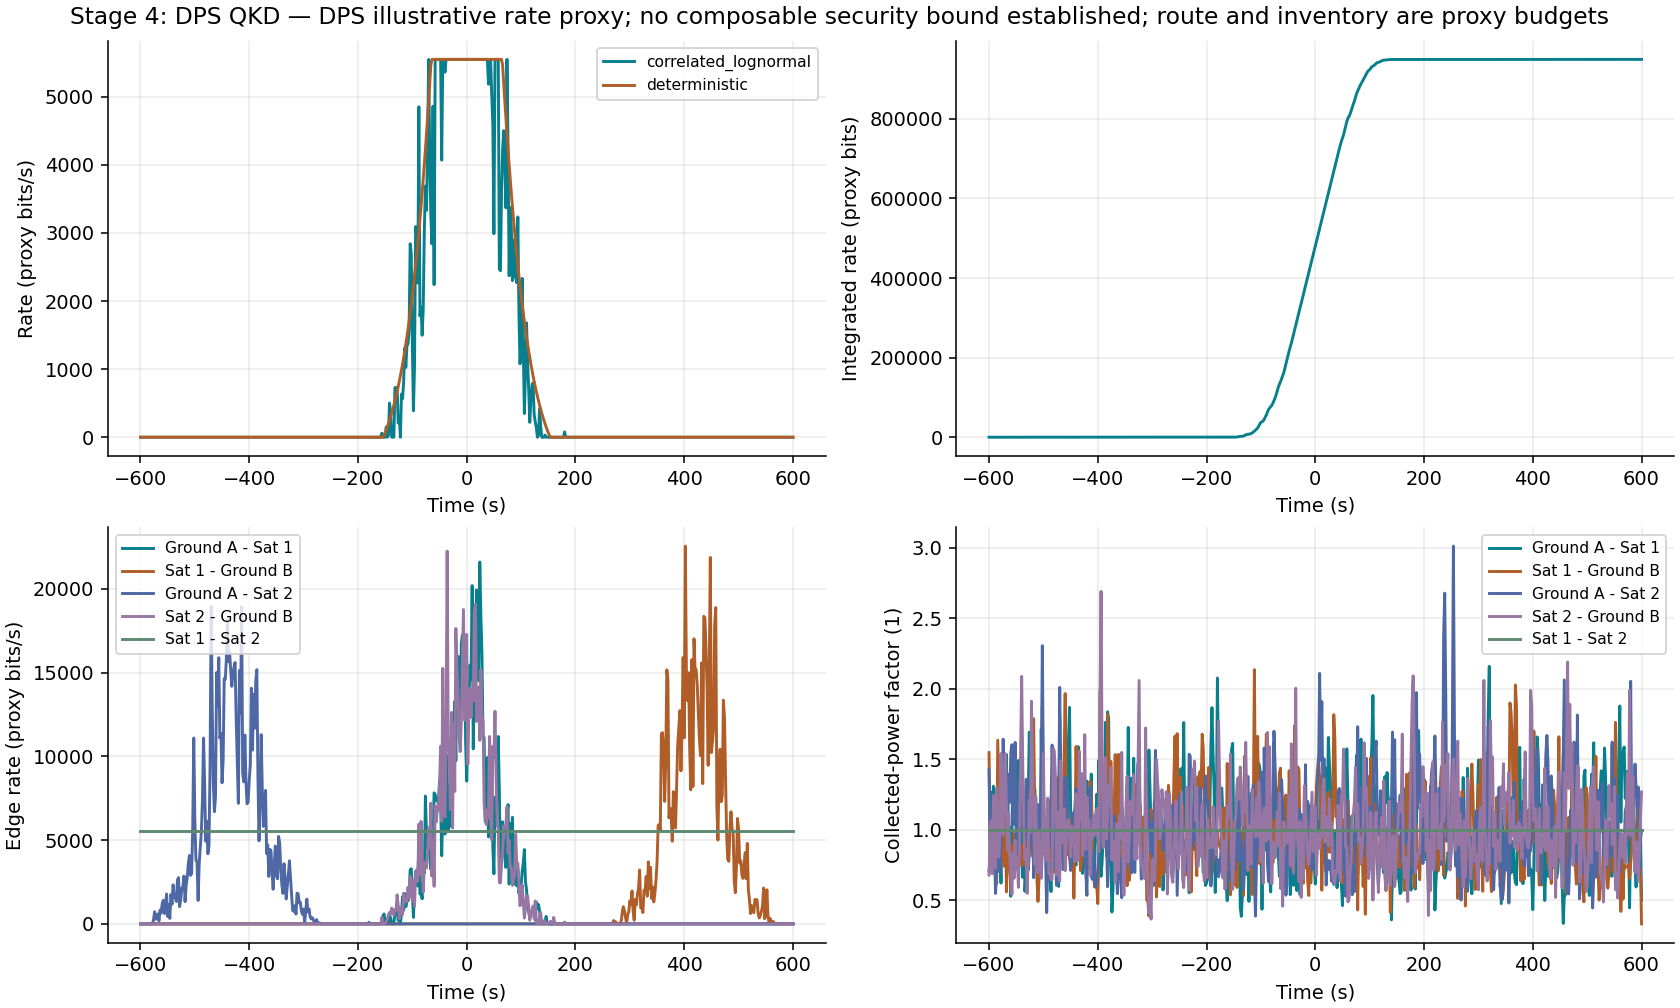

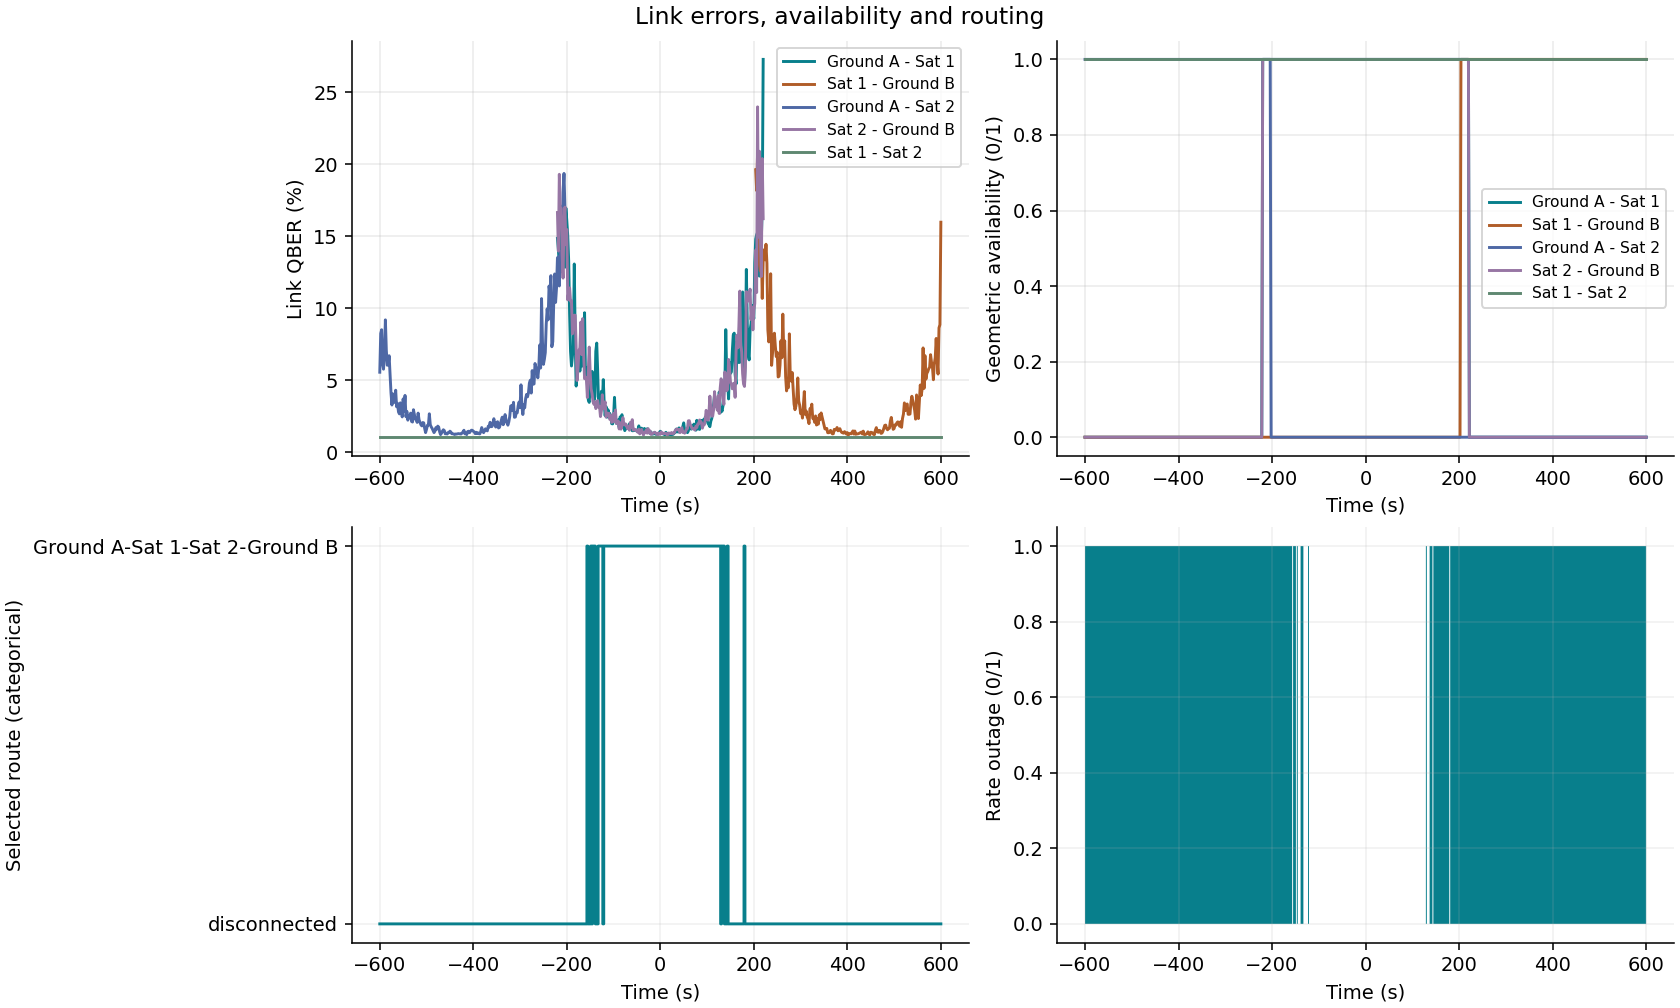

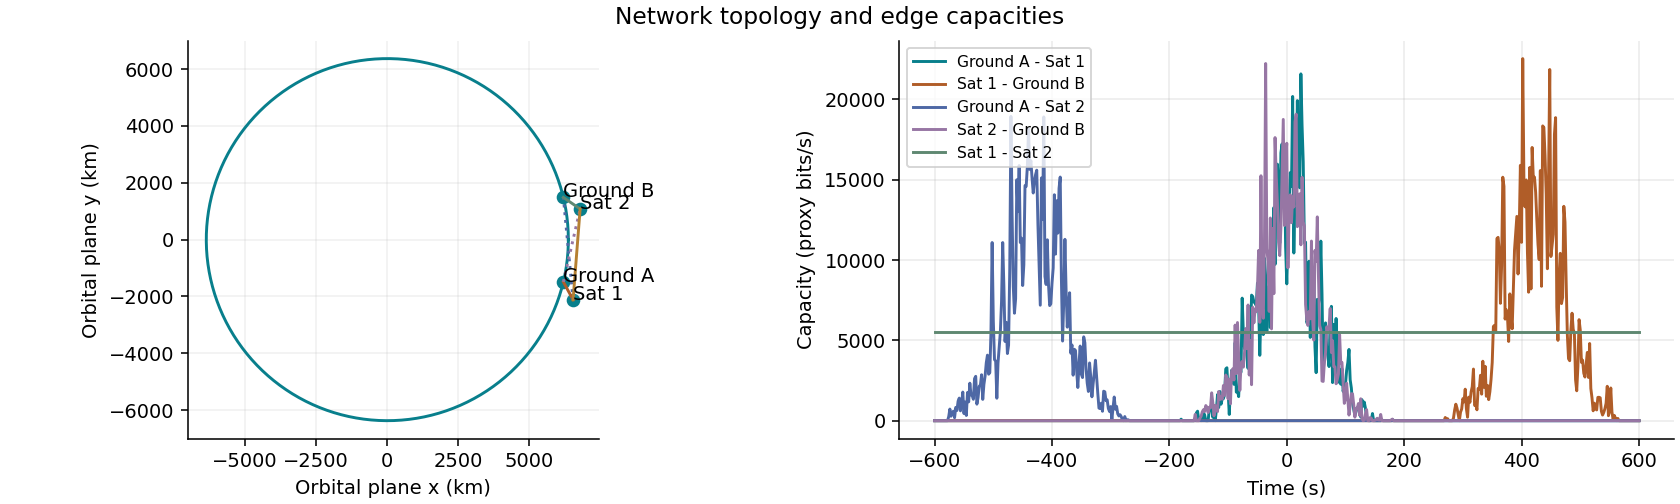

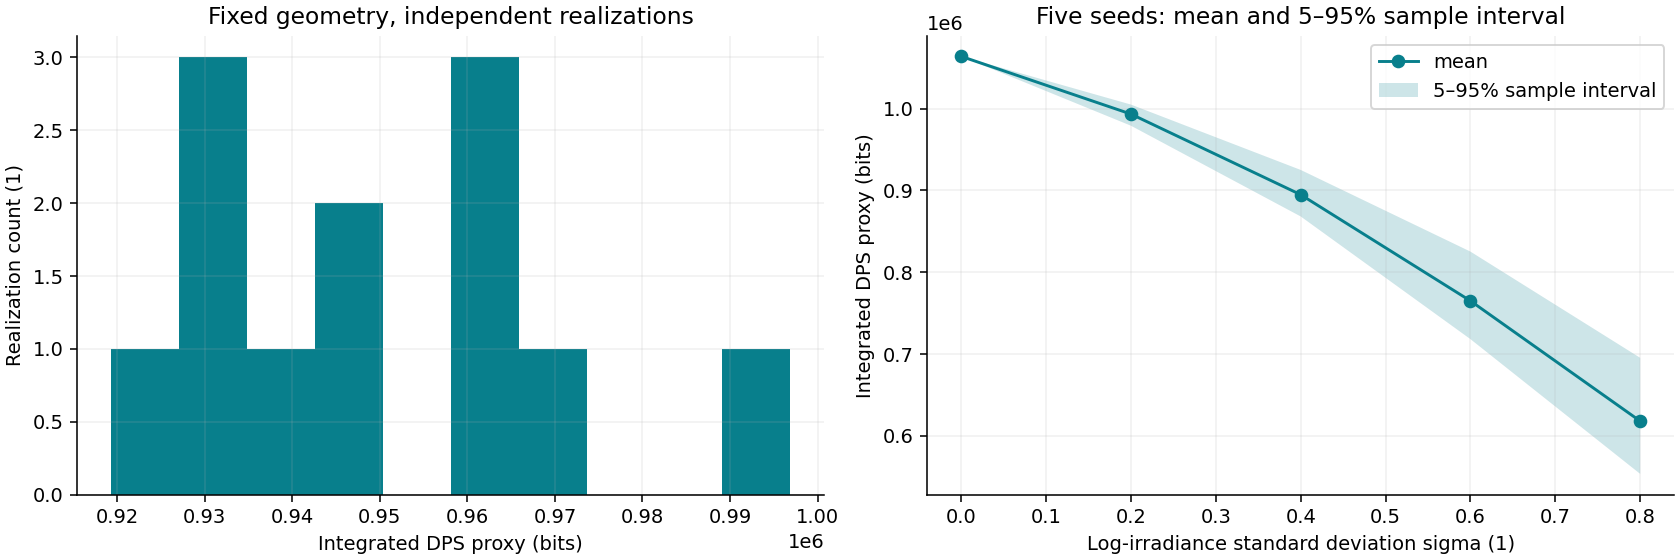

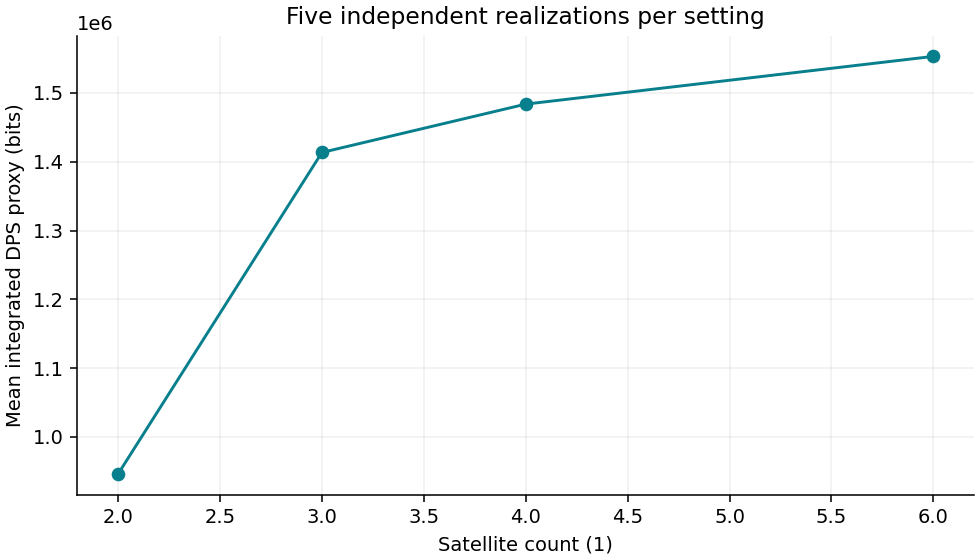

Default study HTML: d:\IIT Class\Project\Submission\4-Two Ground and Multiple Satellites\dps_turbulence_results\report.html


In [9]:
default_study_folder = project_root / '4-Two Ground and Multiple Satellites' / "dps_turbulence_results"
default_study_result, realization_rows, sensitivity_rows = study(4, default_study_folder)
display(Markdown("| Seed | Integrated DPS proxy (bits) | Outage sample fraction |\n|---|---|---|\n" +
    "\n".join(f"| {row['seed']} | {row['integrated_rate_bits']:.6g} | {row['outage_fraction']:.4f} |" for row in realization_rows)))
for image_path in sorted(default_study_folder.glob("figure_*.png")):
    display(Image(filename=str(image_path)))
print("Default study HTML:", default_study_folder / "report.html")
